In [1]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, classification_report, roc_curve, roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import recall_score, confusion_matrix, precision_score, f1_score, accuracy_score, classification_report

In [2]:
df1 = pd.read_csv("../dataset/train.csv")
X_train = df1.drop(columns = ['Churn'])
y_train = df1['Churn'].values
df2 = pd.read_csv("../dataset/test.csv")
X_test = df2.drop(columns = ['Churn'])
y_test = df2['Churn'].values

In [3]:
#kết nối với thiên nhiên nè
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
#train
dt_model.fit(X_train, y_train)
#test
y_pred_dt = dt_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Decision Tree Report:\n", classification_report(y_test, y_pred_dt))

Accuracy: 0.7889125799573561
Decision Tree Report:
               precision    recall  f1-score   support

           0       0.81      0.93      0.87      1033
           1       0.67      0.41      0.51       374

    accuracy                           0.79      1407
   macro avg       0.74      0.67      0.69      1407
weighted avg       0.77      0.79      0.77      1407



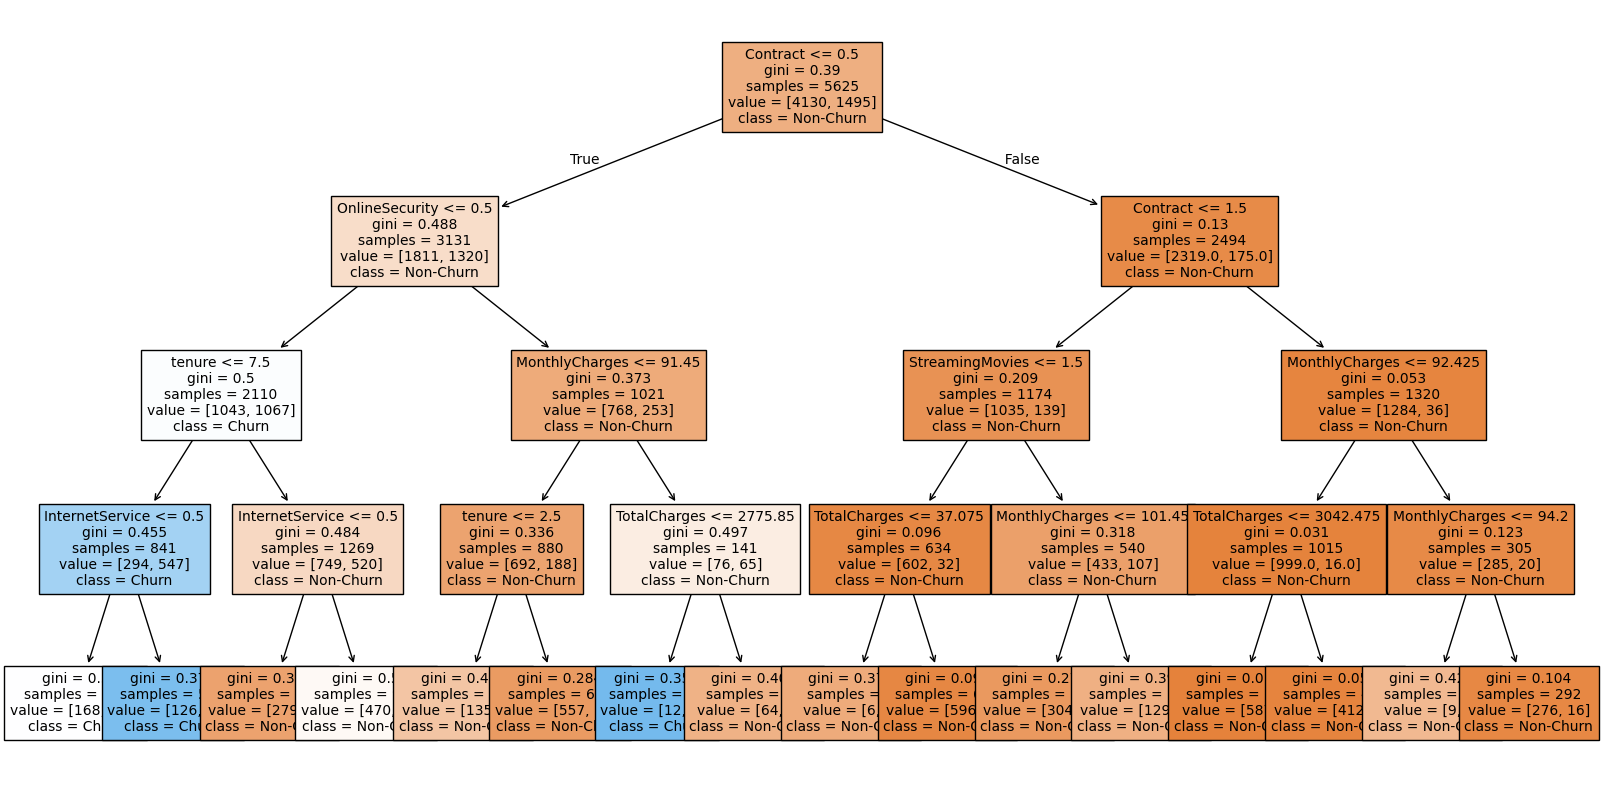

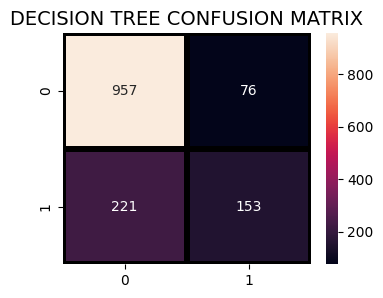

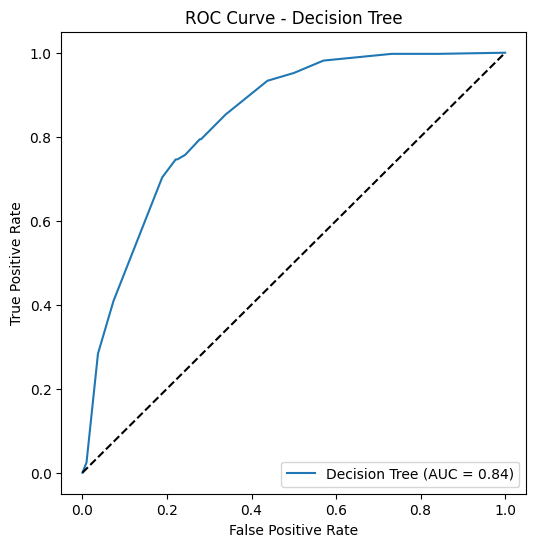

In [4]:
#visualize cây
plt.figure(figsize=(20,10))
plot_tree(dt_model, feature_names=X_train.columns, class_names=["Non-Churn","Churn"], filled=True, fontsize=10)
plt.show()

#tiếp tục confusion mt và ROC curve như trên
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True,fmt = "d",linecolor="k",linewidths=3)
plt.title("DECISION TREE CONFUSION MATRIX",fontsize=14)
plt.show()

y_prob_dt = dt_model.predict_proba(X_test)[:, 1]
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_prob_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)
plt.figure(figsize=(6,6))
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend(loc="lower right")
plt.show()

Đánh giá sơ bộ:
+ FN = 221 cao: bỏ sót rất nhiều churn (model )
+ Recall (churn) = 153 / (153 + 221) ≈ 0.41 : Dự đoán non-churn rất tốt, nhưng churn thì như quần què
+ AUC ≈ 0.84: model có tiềm năng dự đoán churn tốt nếu áp dụng đúng threshold
Có thể thấy threshold mặc định đang 0.5 đang không phù hợp (bài toán churn ưu tiên chỉ số)

Upgrade Decision Tree model

1. Chỉnh threshold thấp hơn (khoảng 0.3)

In [5]:
dt_thresh = DecisionTreeClassifier(max_depth=4, random_state=42)

dt_thresh.fit(X_train, y_train)

y_prob_thresh = dt_thresh.predict_proba(X_test)[:, 1]
y_pred_thresh = (y_prob_thresh > 0.3).astype(int)

print("=== Threshold (0.3) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_thresh))
print(classification_report(y_test, y_pred_thresh))

=== Threshold (0.3) ===
Accuracy: 0.767590618336887
              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1033
           1       0.55      0.75      0.63       374

    accuracy                           0.77      1407
   macro avg       0.72      0.76      0.73      1407
weighted avg       0.80      0.77      0.78      1407



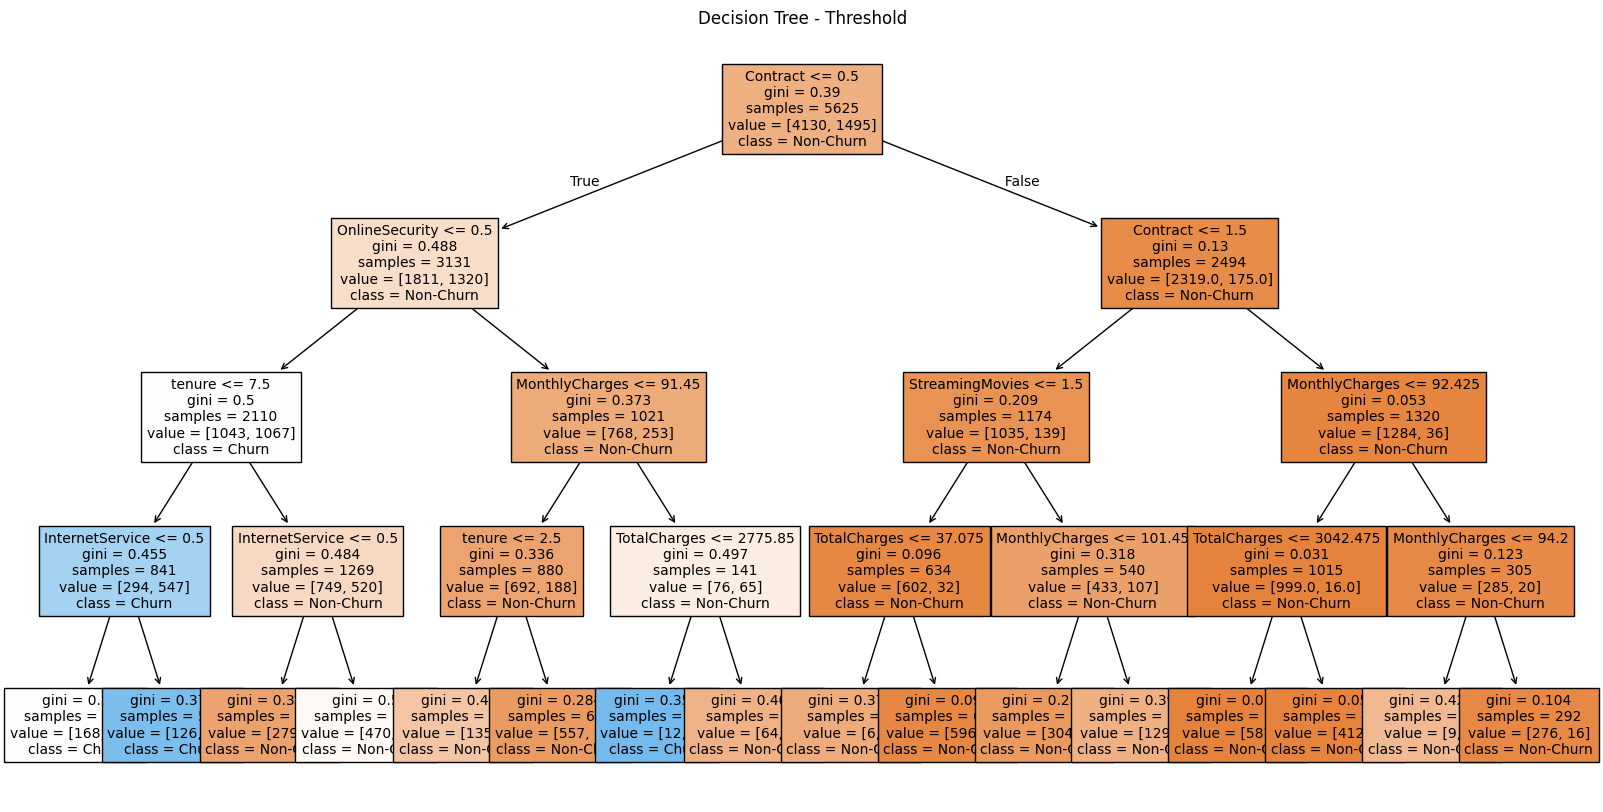

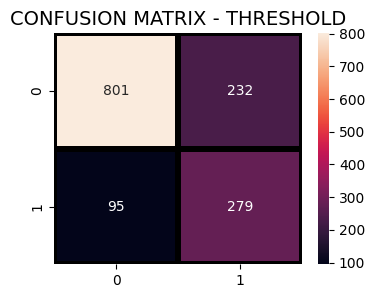

In [6]:
# tree (giống baseline vì model không đổi)
plt.figure(figsize=(20,10))
plot_tree(dt_thresh, feature_names=X_train.columns,
          class_names=["Non-Churn","Churn"],
          filled=True, fontsize=10)
plt.title("Decision Tree - Threshold")
plt.show()

# confusion matrix
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_thresh),
            annot=True, fmt="d", linecolor="k", linewidths=3)
plt.title("CONFUSION MATRIX - THRESHOLD", fontsize=14)
plt.show()

2. Handle Class Imbalance

In [7]:
dt_balanced = DecisionTreeClassifier(
    max_depth=4,
    class_weight='balanced',
    random_state=42
)

dt_balanced.fit(X_train, y_train)

y_pred_balanced = dt_balanced.predict(X_test)

print("=== Class Weight ===")
print("Accuracy:", accuracy_score(y_test, y_pred_balanced))
print(classification_report(y_test, y_pred_balanced))

=== Class Weight ===
Accuracy: 0.744136460554371
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1033
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.76      1407



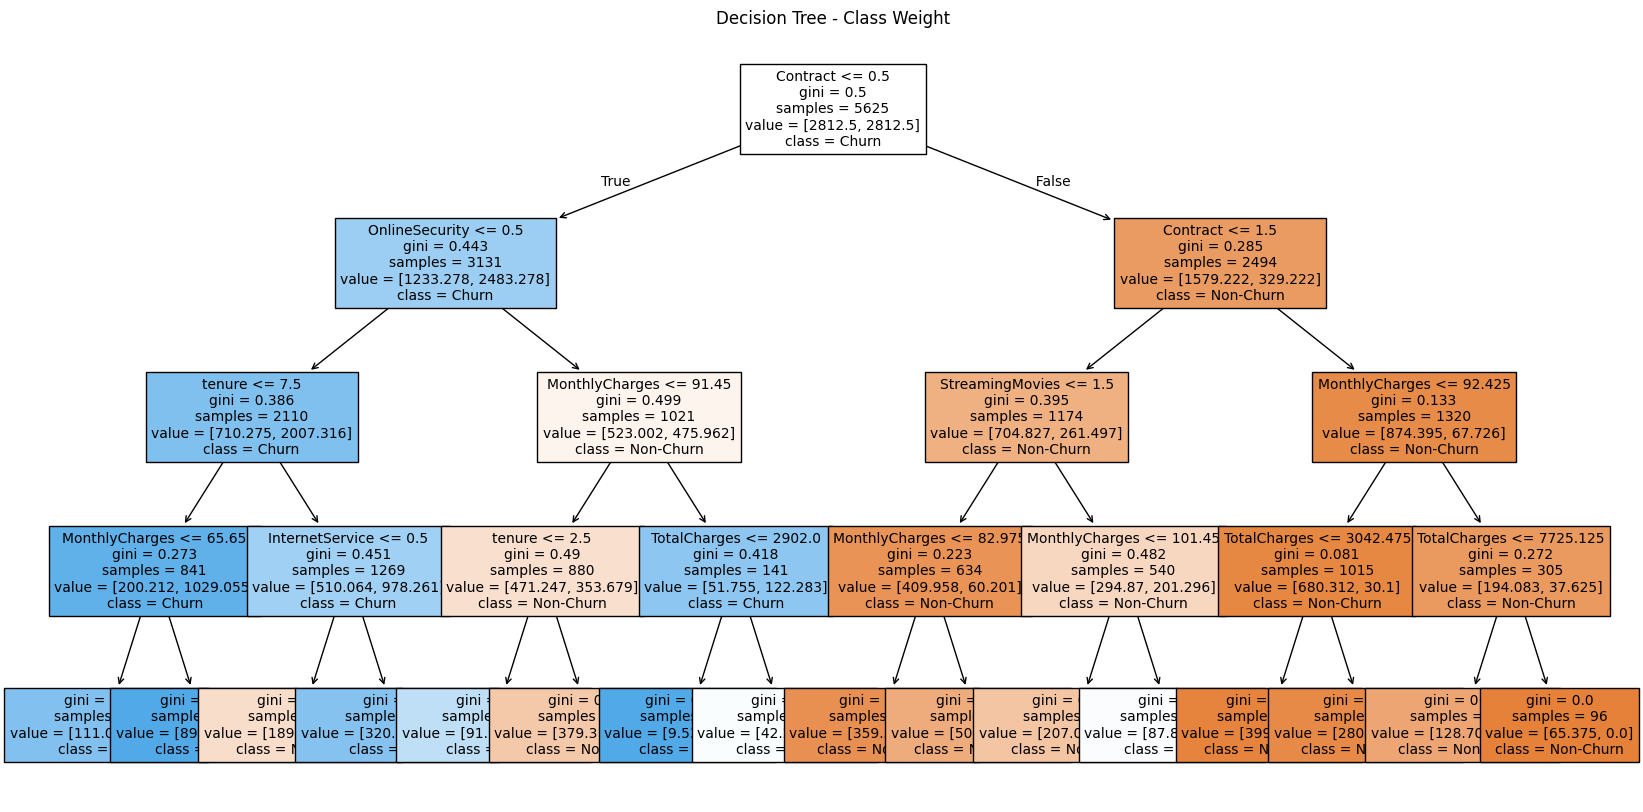

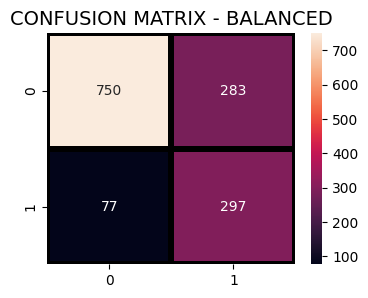

In [8]:
plt.figure(figsize=(20,10))
plot_tree(dt_balanced, feature_names=X_train.columns,
          class_names=["Non-Churn","Churn"],
          filled=True, fontsize=10)
plt.title("Decision Tree - Class Weight")
plt.show()

plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_balanced),
            annot=True, fmt="d", linecolor="k", linewidths=3)
plt.title("CONFUSION MATRIX - BALANCED", fontsize=14)
plt.show()

4. Limit Tree Complexity

In [9]:
dt_limited = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=20,
    random_state=42
)

dt_limited.fit(X_train, y_train)

y_pred_limited = dt_limited.predict(X_test)

print("=== Min Samples Leaf ===")
print("Accuracy:", accuracy_score(y_test, y_pred_limited))
print(classification_report(y_test, y_pred_limited))

=== Min Samples Leaf ===
Accuracy: 0.7889125799573561
              precision    recall  f1-score   support

           0       0.81      0.93      0.87      1033
           1       0.67      0.41      0.51       374

    accuracy                           0.79      1407
   macro avg       0.74      0.67      0.69      1407
weighted avg       0.77      0.79      0.77      1407



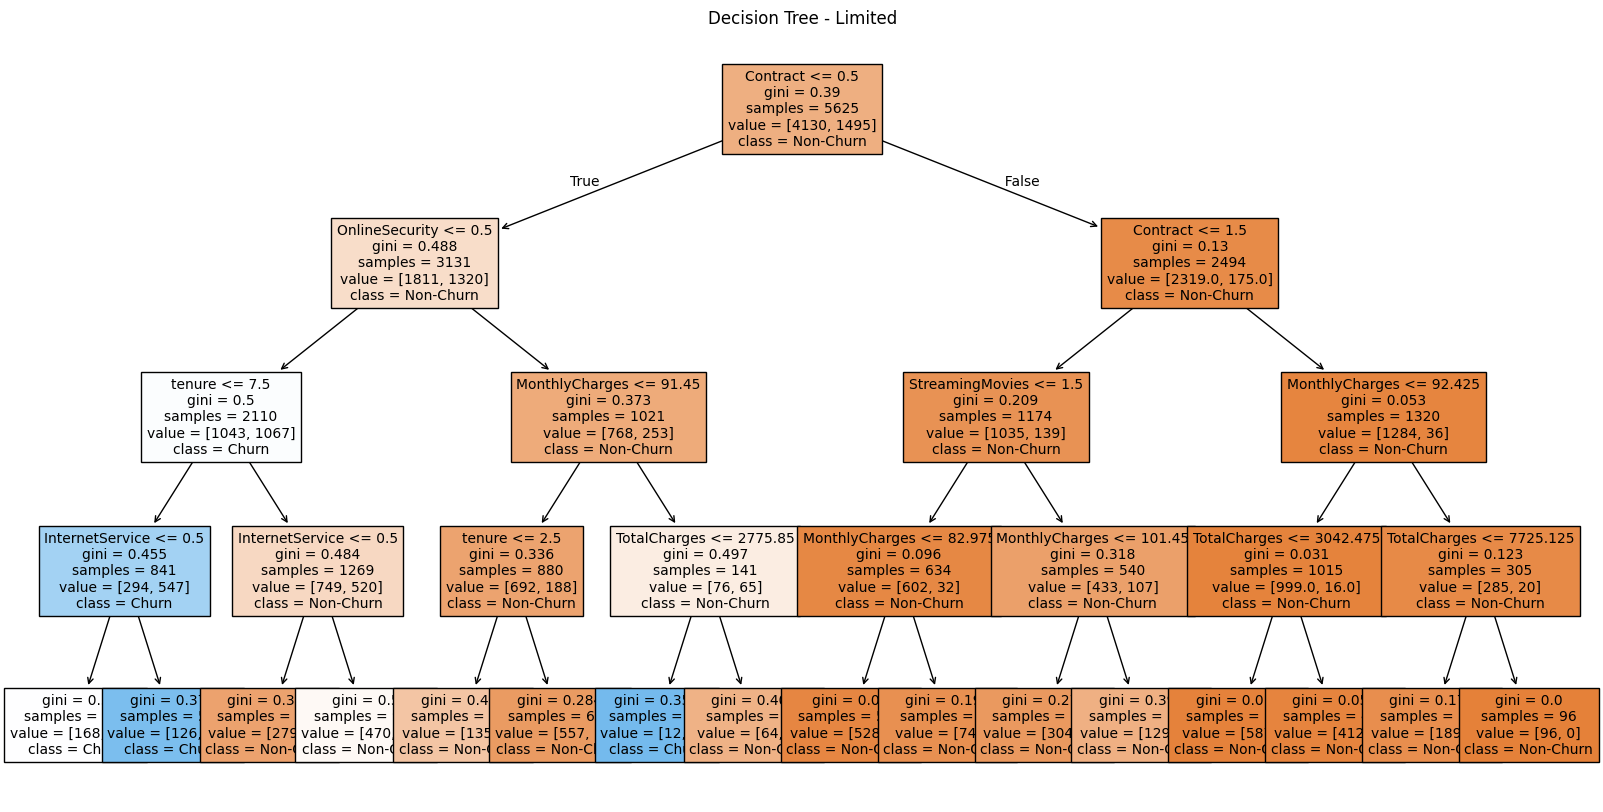

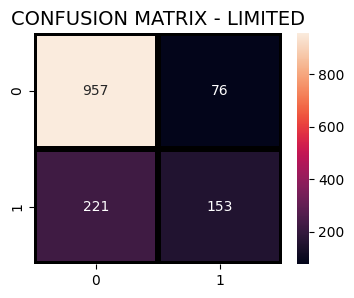

In [10]:
plt.figure(figsize=(20,10))
plot_tree(dt_limited, feature_names=X_train.columns,
          class_names=["Non-Churn","Churn"],
          filled=True, fontsize=10)
plt.title("Decision Tree - Limited")
plt.show()

plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_limited),
            annot=True, fmt="d", linecolor="k", linewidths=3)
plt.title("CONFUSION MATRIX - LIMITED", fontsize=14)
plt.show()

5. Apply Pruning

In [11]:
dt_pruned = DecisionTreeClassifier(
    max_depth=4,
    ccp_alpha=0.01,
    random_state=42
)

dt_pruned.fit(X_train, y_train)

y_pred_pruned = dt_pruned.predict(X_test)

print("=== Pruning ===")
print("Accuracy:", accuracy_score(y_test, y_pred_pruned))
print(classification_report(y_test, y_pred_pruned))

=== Pruning ===
Accuracy: 0.7896233120113717
              precision    recall  f1-score   support

           0       0.81      0.94      0.87      1033
           1       0.69      0.39      0.49       374

    accuracy                           0.79      1407
   macro avg       0.75      0.66      0.68      1407
weighted avg       0.78      0.79      0.77      1407



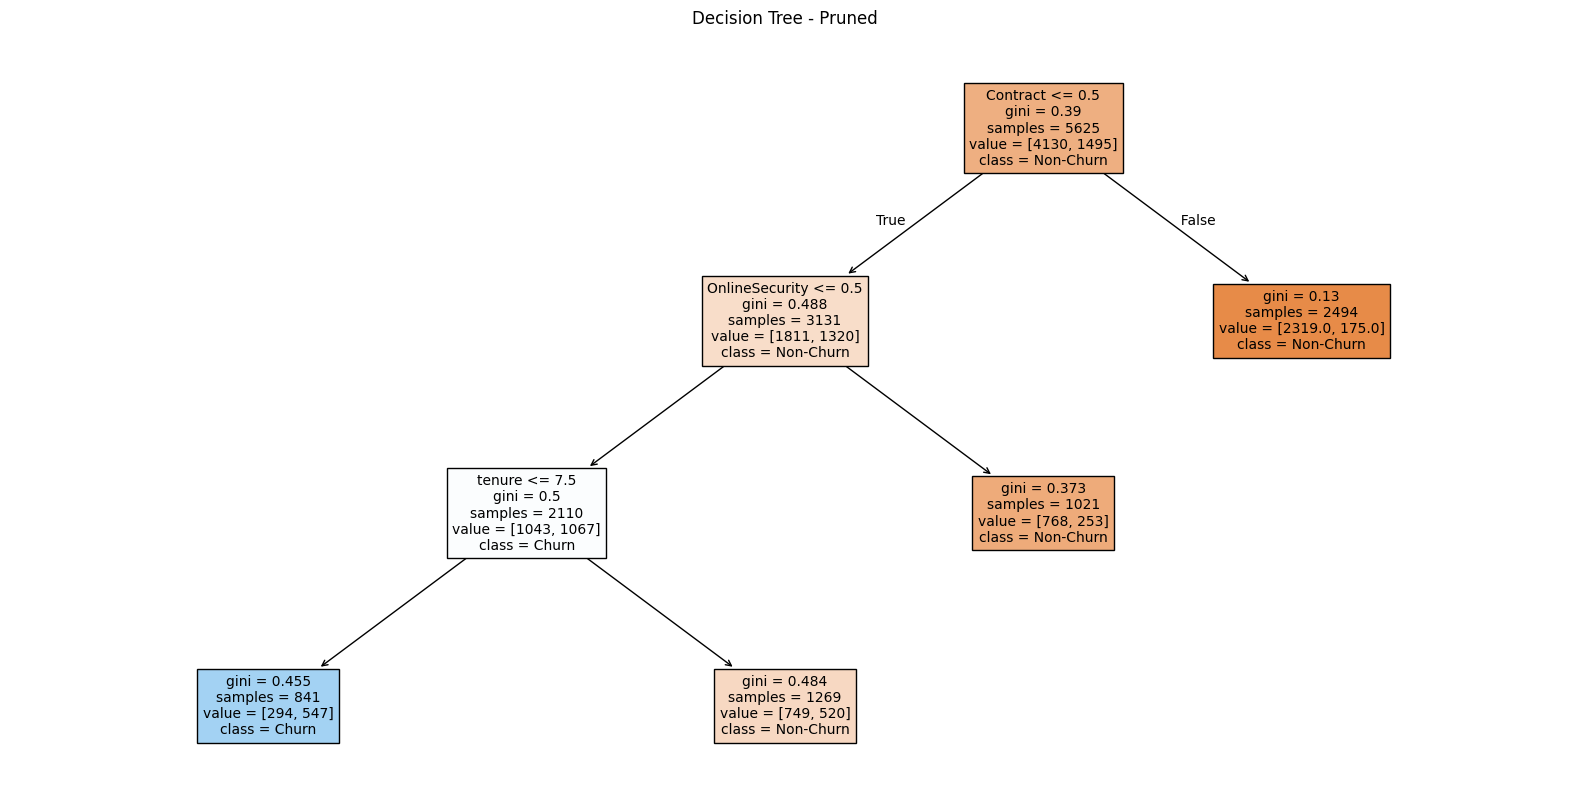

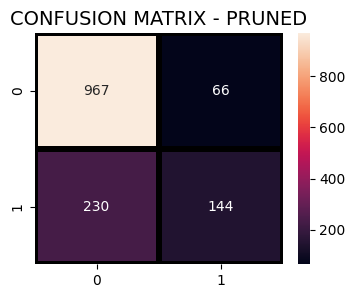

In [12]:
plt.figure(figsize=(20,10))
plot_tree(dt_pruned, feature_names=X_train.columns,
          class_names=["Non-Churn","Churn"],
          filled=True, fontsize=10)
plt.title("Decision Tree - Pruned")
plt.show()

plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_pruned),
            annot=True, fmt="d", linecolor="k", linewidths=3)
plt.title("CONFUSION MATRIX - PRUNED", fontsize=14)
plt.show()

6. Con cu sần: Kết hợp 2 cách nâng cấp đầu tiên, 2 cách còn lại cút vì vừa ko giúp được gì lại còn phá

In [13]:
# model
dt_final = DecisionTreeClassifier(
    max_depth=4,
    class_weight='balanced',
    random_state=42
)

# train
dt_final.fit(X_train, y_train)

# predict probability
y_prob_final = dt_final.predict_proba(X_test)[:, 1]

# adjust threshold
threshold = 0.3
y_pred_final = (y_prob_final > threshold).astype(int)

# evaluation
print("=== Final Decision Tree ===")
print("Threshold:", threshold)
print("Accuracy:", accuracy_score(y_test, y_pred_final))
print("Decision Tree Report:\n", classification_report(y_test, y_pred_final))

=== Final Decision Tree ===
Threshold: 0.3
Accuracy: 0.6247334754797441
Decision Tree Report:
               precision    recall  f1-score   support

           0       0.97      0.51      0.66      1033
           1       0.41      0.95      0.57       374

    accuracy                           0.62      1407
   macro avg       0.69      0.73      0.62      1407
weighted avg       0.82      0.62      0.64      1407



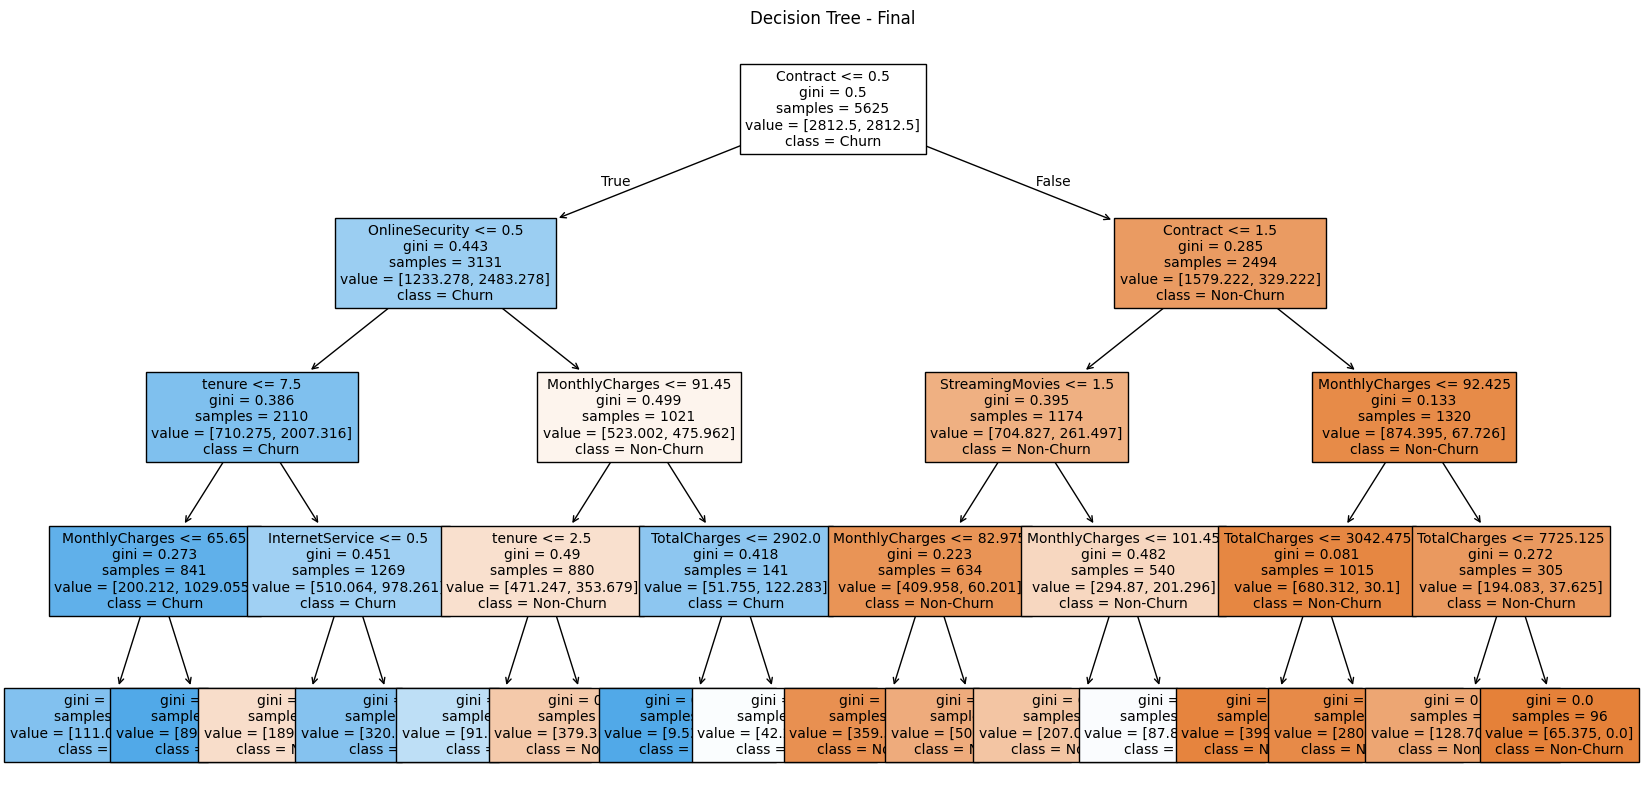

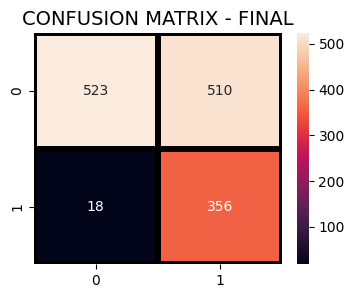

In [14]:
# visualize tree
plt.figure(figsize=(20,10))
plot_tree(dt_final, feature_names=X_train.columns,
          class_names=["Non-Churn","Churn"],
          filled=True, fontsize=10)
plt.title("Decision Tree - Final")
plt.show()

# confusion matrix
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_final),
            annot=True, fmt="d", linecolor="k", linewidths=3)
plt.title("CONFUSION MATRIX - FINAL", fontsize=14)
plt.show()